# The labelled controls through the whole chain, minute by minute

## Scope

`4_01` and `4_02` run on peptides drawn at random or stratified by predicted
potency. Neither runs on the one set of peptides whose serum fate is **annotated**
and whose MIC is **measured**, which is the only set where every link of the chain
can be looked at on the same molecules:

> hazard $\rightarrow$ where the first cut falls $\rightarrow$ what the fragments
> are worth $\rightarrow$ how the killing power decays minute by minute

This notebook does that. Ten peptides, each carrying a `stable` or `labile`
annotation and a measured MIC, are pushed through the full model and every
intermediate quantity is reported **split by that label**, so a reader can see at
which link — if any — the annotated groups come apart.

The label is weak evidence and `3_03` says exactly how weak: two unrelated
sources, three of ten peptides recorded inactive, both `stable` peptides of the
palaeogenomics source inactive, and the label confounded with length in opposite
directions between the sources. Nothing here is a validation. It is the picture of
what the model does to peptides a biologist has called stable or labile, at the
resolution the question is asked at.

## What is shown, and why at one-minute resolution

| Level | Quantity | Why it needs the labels |
| --- | --- | --- |
| hazard | $\Lambda$ and $1/\Lambda$ | whether labile peptides are attacked faster at all |
| single cut | the exact first-cut distribution | whether the first event lands somewhere that costs activity |
| fragments | potency of each product | whether a cut on a labile peptide destroys more than on a stable one |
| time | effective MIC and activity per minute | how fast the killing power actually goes |

The time axis is in minutes because that is the resolution the biological question
is asked at — a peptide that loses half its activity in four minutes and one that
takes four hours are different molecules for a dosing decision, and a horizon
reported as a single number hides which one you have.

**The time axis is provisional.** `3_01` fitted the constant that converts the
hazard into minutes and could not show that the modelled hazard orders measured
degradation rates. Comparisons between peptides under one weighting do not depend
on that constant; statements about absolute minutes do.

## Inputs and outputs

Inputs: `data/peptides_data/peptides_mic/controls_mic.csv`,
`results/2_07_model_panel.csv`, `results/3_01_time_axis_calibration.csv`,
`data/merops/`, `data/reference/human_proteome/composition.json`, the APEX
ensemble.

Outputs: `results/4_04_control_hazard.csv`,
`results/4_04_control_single_cut.csv`, `results/4_04_control_trajectories.csv`,
`results/4_04_control_budgets.csv`.

In [1]:
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

import _analysis_common as common
from pep_compass.optimization.components.helpers.activity import (
    activity_budget,
    activity_transform_registry,
    build_activity_transform,
)
from pep_compass.optimization.components.helpers.proteolysis import (
    EventGeometry,
    Fragment,
    ProteaseKinetics,
    first_cut_distribution,
    load_amino_acid_background,
    load_protease_panel,
    simulate_trajectory,
    state_at,
)
from pep_compass.optimization.components.oracles.strategies.apex.predictor import APEXPredictor

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
SCORE_SLOPE = common.SCORE_SLOPE_PER_DECADE * np.log(10.0)
MIN_ACTIVE_LENGTH = common.MIN_ACTIVE_FRAGMENT_LENGTH
STRAIN_COLUMN = 0
# One minute is the resolution the biological question is asked at; the horizon is
# long enough that a peptide with a four-hour half-life still shows its decay.
HORIZON_MINUTES = 240.0
TIME_STEP_MINUTES = 1.0
N_TRAJECTORIES = 120
MAX_EVENTS = 40
# The dose places the intact peptide at exactly one MIC, so every transform operates
# where its threshold is, and the effective MIC of the mixture is directly readable.
DOSE_MULTIPLE = 1.0
SEED = common.SEED

In [3]:
rng = np.random.default_rng(SEED)
times = np.arange(0.0, HORIZON_MINUTES + TIME_STEP_MINUTES, TIME_STEP_MINUTES)
human_background = load_amino_acid_background(
    common.ROOT / "data" / "reference" / "human_proteome" / "composition.json"
)
panel = pd.read_csv(common.RESULTS_ROOT / "2_07_model_panel.csv")
calibration = pd.read_csv(common.RESULTS_ROOT / "3_01_time_axis_calibration.csv")
controls = pd.read_csv(common.CONTROLS_MIC_CSV)
controls["length"] = controls["sequence"].str.len()

print(f"labelled controls: {len(controls)} ({controls['serum_fate'].value_counts().to_dict()})")
print(f"time grid: {len(times)} points at {TIME_STEP_MINUTES:.0f} min to {HORIZON_MINUTES:.0f} min")
print(controls[["short", "serum_fate", "active", "length", "source"]].to_string(index=False))

labelled controls: 10 ({'labile': 6, 'stable': 4})
time grid: 241 points at 1 min to 240 min
        short serum_fate  active  length           source
     Mammutin     labile    True      15          OmegAMP
       bZIP-8     stable    True      30          OmegAMP
       GQ20-4     labile    True      20          OmegAMP
        pa4-1     stable    True      33          OmegAMP
   sarcotoxin     labile    True      39          OmegAMP
Mammuthusin-2     stable   False      14 Paleogenomics SI
 Hydrodamin-1     labile    True      15 Paleogenomics SI
Megalocerin-1     labile    True      30 Paleogenomics SI
  Elephasin-2     stable   False      13 Paleogenomics SI
  Mylodonin-2     labile   False      12 Paleogenomics SI


## The panel, and the fragment potencies of the controls

Every state a trajectory can reach is a set of contiguous subsequences of one
control peptide, so the whole set of fragments is known before any simulation
runs. They are predicted once, which turns the simulation into table lookups.

In [4]:
human_panel = load_protease_panel(34, merops_root=common.MEROPS_ROOT, kind="logprob", device="cpu")
matrices = human_panel.matrices.numpy().astype(np.float64)
index_of = {code: index for index, code in enumerate(human_panel.codes)}
available = panel[panel["merops_code"].isin(index_of)].copy()
with_abundance = available.dropna(subset=["abundance_pg_per_l"]).copy()
alpha_of = dict(zip(calibration["weighting"], calibration["alpha"]))
abundance_weights = (
    with_abundance["abundance_pg_per_l"] / with_abundance["abundance_pg_per_l"].median()
).to_numpy()


def build(frame: pd.DataFrame, weights: np.ndarray, slope: float, intercept: float) -> ProteaseKinetics:
    """Assemble the panel for one weighting.

    :param frame: Panel rows to include.
    :param weights: Per-protease weight.
    :param slope: Score-to-log-intensity coefficient; zero switches the score off.
    :param intercept: Calibrated global offset.
    :return: The assembled kinetics.
    """

    return ProteaseKinetics(
        matrices=np.stack([matrices[index_of[code]] for code in frame["merops_code"]]),
        geometries=tuple(EventGeometry(value) for value in frame["event_geometry"]),
        weights=np.asarray(weights, dtype=float),
        codes=tuple(frame["merops_code"]),
        intercept=intercept,
        slope=slope,
    )


variants = {
    "uniform": build(available, np.ones(len(available)), SCORE_SLOPE, alpha_of["uniform"]),
    "concentration": build(with_abundance, abundance_weights, SCORE_SLOPE, alpha_of["concentration"]),
    "concentration_only": build(with_abundance, abundance_weights, 0.0, alpha_of["concentration"]),
}
protease_names = dict(zip(panel["merops_code"], panel["name"]))

needed = sorted(
    {
        sequence[start:end]
        for sequence in controls["sequence"]
        for start in range(len(sequence))
        for end in range(start + MIN_ACTIVE_LENGTH, len(sequence) + 1)
    }
)
predictor = APEXPredictor(model="full", device="cpu")
mic_of = dict(zip(needed, predictor.predict(needed)[:, STRAIN_COLUMN]))
print(f"fragments predicted: {len(mic_of):,}")

fragments predicted: 1,507


## Level 1: the hazard, split by label

The first quantity the model produces for a peptide is its total intensity, and
the expected time to the first cut is its reciprocal. If the annotation
corresponded to anything the model sees, this is where it would already show.

In [5]:
hazard_rows = []
for row in controls.itertuples():
    for weighting, kinetics in variants.items():
        bond_probability, protease_share, mean_time = first_cut_distribution(
            row.sequence, kinetics, human_background
        )
        dominant = int(np.argmax(protease_share)) if protease_share.size else -1
        hazard_rows.append(
            {
                "short": row.short,
                "serum_fate": row.serum_fate,
                "active": row.active,
                "source": row.source,
                "length": row.length,
                "weighting": weighting,
                "hazard_per_minute": 1.0 / mean_time if np.isfinite(mean_time) and mean_time > 0 else np.inf,
                "mean_time_minutes": mean_time,
                "dominant_protease": kinetics.codes[dominant] if dominant >= 0 else "",
                "dominant_name": protease_names.get(kinetics.codes[dominant], "") if dominant >= 0 else "",
                "dominant_share": float(protease_share[dominant]) if dominant >= 0 else np.nan,
                "top_bond_probability": float(bond_probability.max()) if bond_probability.size else np.nan,
            }
        )

hazard = pd.DataFrame(hazard_rows)
print(
    hazard.pivot_table(index=["short", "serum_fate", "length"], columns="weighting", values="mean_time_minutes")
    .round(1)
    .to_string()
)
print()
for weighting in variants:
    subset = hazard[hazard["weighting"] == weighting]
    labile = subset.loc[subset["serum_fate"] == "labile", "hazard_per_minute"].to_numpy()
    stable = subset.loc[subset["serum_fate"] == "stable", "hazard_per_minute"].to_numpy()
    statistic, p_value = mannwhitneyu(labile, stable, alternative="greater")
    print(f"{weighting:20s} AUC {statistic / (len(labile) * len(stable)):.3f}, p {p_value:.3f}")

weighting                        concentration  concentration_only  uniform
short         serum_fate length                                            
Elephasin-2   stable     13              761.8               177.3    700.0
GQ20-4        labile     20              172.1               112.0    241.0
Hydrodamin-1  labile     15              576.0               152.0    699.9
Mammuthusin-2 stable     14             2918.5               163.7   1156.4
Mammutin      labile     15               98.7               152.0    398.8
Megalocerin-1 labile     30               76.1                73.4    285.8
Mylodonin-2   labile     12             3351.4               193.4   1264.3
bZIP-8        stable     30               47.2                73.4    278.5
pa4-1         stable     33               72.8                66.5    245.4
sarcotoxin    labile     39              182.9                56.0    147.9

uniform              AUC 0.583, p 0.381
concentration        AUC 0.417, p 0.695
concent

### Reading the figure

Left: the expected time to the first cut for each control, stable above labile.
Separation would show as two non-overlapping rows. Right: which protease carries
the hazard of each peptide, since a model whose predictions all come from one
enzyme is making one prediction repeatedly.

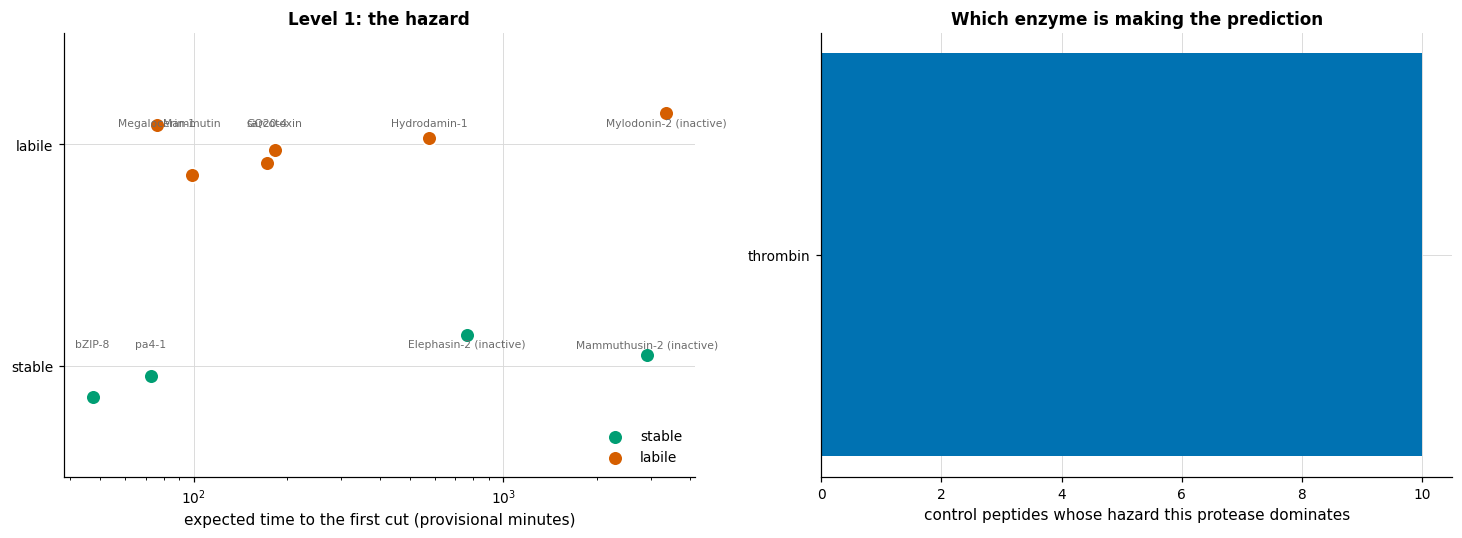

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.0))

ax = axes[0]
shown = hazard[hazard["weighting"] == "concentration"]
for offset, (fate, colour) in enumerate(
    zip(("stable", "labile"), (common.CATEGORICAL_COLORS[2], common.CATEGORICAL_COLORS[1]))
):
    group = shown[shown["serum_fate"] == fate]
    ax.scatter(group["mean_time_minutes"], np.full(len(group), offset) + np.linspace(-0.14, 0.14, len(group)),
               s=95, color=colour, edgecolor="white", linewidth=1.2, zorder=3, label=fate)
    for row in group.itertuples():
        ax.annotate(f"{row.short}{'' if row.active else ' (inactive)'}",
                    (row.mean_time_minutes, offset), textcoords="offset points",
                    xytext=(0, 12), ha="center", fontsize=7, color=common.NEUTRAL)
ax.set_xscale("log")
ax.set_yticks([0, 1])
ax.set_yticklabels(["stable", "labile"])
ax.set_ylim(-0.5, 1.5)
ax.set_xlabel("expected time to the first cut (provisional minutes)")
ax.set_title("Level 1: the hazard")
ax.legend(frameon=False, loc="lower right")

ax = axes[1]
dominant = shown.groupby(["dominant_name"]).size().sort_values()
ax.barh(dominant.index, dominant.to_numpy(), color=common.CATEGORICAL_COLORS[0], height=0.6)
ax.set_xlabel("control peptides whose hazard this protease dominates")
ax.set_title("Which enzyme is making the prediction")
fig.tight_layout()
plt.show()

## Level 2: the single cut, and what it costs

The first cleavage is exact, so no simulation is needed for it. For every control
peptide each candidate bond is evaluated: its probability of being the first
event, and the potency the resulting pair of fragments would leave behind.

In [7]:
def state_potency(parent: str, fragments: tuple[Fragment, ...], dose: float) -> float:
    """Return the potency sum of one state.

    :param parent: Parent peptide sequence.
    :param fragments: Fragments held in the state.
    :param dose: Molar concentration each fragment inherits.
    :return: The potency sum, in multiples of the parent's own MIC.
    """

    total = 0.0
    for fragment in fragments:
        piece = parent[fragment.start : fragment.end]
        if len(piece) < MIN_ACTIVE_LENGTH:
            continue
        mic = mic_of.get(piece)
        if mic is not None and mic > 0:
            total += dose / float(mic)
    return total


single_cut_rows = []
for row in controls.itertuples():
    sequence = row.sequence
    parent_mic = mic_of.get(sequence)
    if parent_mic is None or parent_mic <= 0:
        continue
    dose = DOSE_MULTIPLE * float(parent_mic)
    intact = state_potency(sequence, (Fragment(0, len(sequence)),), dose)
    for weighting, kinetics in variants.items():
        bond_probability, _, _ = first_cut_distribution(sequence, kinetics, human_background)
        for bond in np.flatnonzero(bond_probability > 0):
            after = (Fragment(0, int(bond) + 1), Fragment(int(bond) + 1, len(sequence)))
            remaining = state_potency(sequence, after, dose)
            single_cut_rows.append(
                {
                    "short": row.short,
                    "serum_fate": row.serum_fate,
                    "weighting": weighting,
                    "bond": int(bond),
                    "bond_label": f"{sequence[bond]}|{sequence[bond + 1]}",
                    "probability": float(bond_probability[bond]),
                    "relative_potency_after": remaining / intact if intact > 0 else np.nan,
                }
            )

single_cut = pd.DataFrame(single_cut_rows)
expected = (
    single_cut.assign(weighted=lambda f: f["probability"] * f["relative_potency_after"])
    .groupby(["short", "serum_fate", "weighting"])
    .agg(expected_relative_potency=("weighted", "sum"),
         worst_case=("relative_potency_after", "min"),
         best_case=("relative_potency_after", "max"))
    .reset_index()
)
print(
    expected[expected["weighting"] == "concentration"]
    .sort_values("expected_relative_potency")
    .round(3).to_string(index=False)
)

        short serum_fate     weighting  expected_relative_potency  worst_case  best_case
  Elephasin-2     stable concentration                      0.121       0.000      0.513
  Mylodonin-2     labile concentration                      0.342       0.000      0.879
 Hydrodamin-1     labile concentration                      0.464       0.000      1.235
     Mammutin     labile concentration                      0.495       0.000      1.354
Mammuthusin-2     stable concentration                      0.529       0.000      1.000
       bZIP-8     stable concentration                      0.634       0.449      1.028
        pa4-1     stable concentration                      0.719       0.582      2.132
Megalocerin-1     labile concentration                      0.947       0.476      1.110
       GQ20-4     labile concentration                      0.964       0.190      1.670
   sarcotoxin     labile concentration                      1.274       0.685      2.187


### Reading the figure

One row per control peptide. Each point is a candidate first cut: its horizontal
position is the potency left behind, its size the probability of it being the
event that fires. A peptide whose likely cuts sit far left loses activity as soon
as it is attacked; one whose likely cuts sit near 1 is cut without consequence.

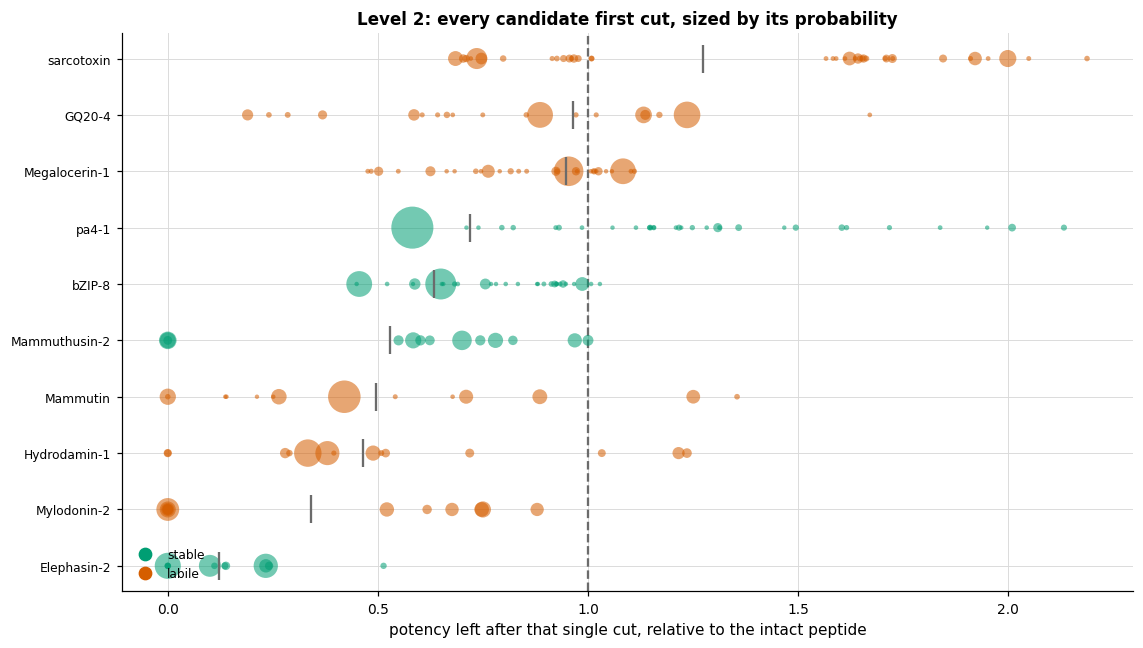

In [8]:
shown = single_cut[single_cut["weighting"] == "concentration"]
order = (
    expected[expected["weighting"] == "concentration"]
    .sort_values("expected_relative_potency")["short"].tolist()
)
fig, ax = plt.subplots(figsize=(10.5, 6.0))
for position, short in enumerate(order):
    group = shown[shown["short"] == short]
    fate = group["serum_fate"].iloc[0]
    colour = common.CATEGORICAL_COLORS[2] if fate == "stable" else common.CATEGORICAL_COLORS[1]
    ax.scatter(group["relative_potency_after"], np.full(len(group), position),
               s=8 + 900 * group["probability"], color=colour, alpha=0.55, edgecolor="none", zorder=3)
    mean_value = float((group["probability"] * group["relative_potency_after"]).sum())
    ax.scatter(mean_value, position, marker="|", s=320, color=common.NEUTRAL, zorder=4)
ax.axvline(1.0, color=common.NEUTRAL, linestyle="--", linewidth=1.5)
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order, fontsize=8)
ax.set_xlabel(r"potency left after that single cut, relative to the intact peptide")
ax.set_title("Level 2: every candidate first cut, sized by its probability")
handles = [
    plt.Line2D([], [], marker="o", linestyle="none", markersize=8, color=colour, label=fate)
    for fate, colour in (("stable", common.CATEGORICAL_COLORS[2]), ("labile", common.CATEGORICAL_COLORS[1]))
]
ax.legend(handles=handles, frameon=False, fontsize=8, loc="lower left")
fig.tight_layout()
plt.show()

## Levels 3 and 4: the effective MIC, minute by minute

The state of a molecule at time $t$ is a set of fragments, and the mixture has a
potency sum $\psi(t)$. Because the dose is one MIC of the intact peptide,
$\psi$ starts at exactly 1 and the **effective MIC of the mixture** is

$$\mathrm{MIC}_{\mathrm{eff}}(t) = \frac{\mathrm{MIC}_{\mathrm{parent}}}{\psi(t)},$$

which is the quantity a microbiologist would read: how much peptide you would now
need to inhibit growth. It starts at the measured MIC and rises as the molecule is
cut. Trajectories are averaged over molecules, because they are independent.

In [9]:
trajectory_rows = []
for row in controls.itertuples():
    sequence = row.sequence
    parent_mic = mic_of.get(sequence)
    if parent_mic is None or parent_mic <= 0:
        continue
    dose = DOSE_MULTIPLE * float(parent_mic)
    intact = state_potency(sequence, (Fragment(0, len(sequence)),), dose)
    for weighting, kinetics in variants.items():
        curves = np.empty((N_TRAJECTORIES, len(times)))
        for replicate in range(N_TRAJECTORIES):
            steps = simulate_trajectory(
                sequence, kinetics, np.random.default_rng(rng.integers(0, 2**32 - 1)),
                float(times[-1]), human_background, max_events=MAX_EVENTS,
            )
            curves[replicate] = [state_potency(sequence, state_at(steps, time), dose) for time in times]
        mean_potency = curves.mean(axis=0) / intact if intact > 0 else np.full(len(times), np.nan)
        trajectory_rows.append(
            pd.DataFrame(
                {
                    "short": row.short,
                    "serum_fate": row.serum_fate,
                    "weighting": weighting,
                    "minute": times,
                    "relative_potency": mean_potency,
                    "effective_mic": np.where(mean_potency > 0, float(parent_mic) / mean_potency, np.inf),
                    "share_uncut": (curves >= intact).mean(axis=0),
                }
            )
        )

trajectories = pd.concat(trajectory_rows, ignore_index=True)
main = trajectories[trajectories["weighting"] == "concentration"]
half = (
    main[main["relative_potency"] <= 0.5]
    .groupby(["short", "serum_fate"])["minute"].min()
    .rename("minutes_to_half_potency").reset_index()
)
print("time to lose half the potency, concentration weighting:")
print(half.sort_values("minutes_to_half_potency").to_string(index=False))
missing = set(main["short"]) - set(half["short"])
if missing:
    print(f"never reached half within {HORIZON_MINUTES:.0f} min: {sorted(missing)}")

time to lose half the potency, concentration weighting:
   short serum_fate  minutes_to_half_potency
Mammutin     labile                    128.0
  bZIP-8     stable                    226.0
never reached half within 240 min: ['Elephasin-2', 'GQ20-4', 'Hydrodamin-1', 'Mammuthusin-2', 'Megalocerin-1', 'Mylodonin-2', 'pa4-1', 'sarcotoxin']


### Reading the figure

The effective MIC of each control over four hours, on a log axis, coloured by its
annotation. A flat line is a peptide the model leaves alone; a rising line is one
losing potency, and the steepness is how fast. The dashed horizontal line is each
peptide's own starting MIC, so a curve crossing far above it has lost most of what
it had.

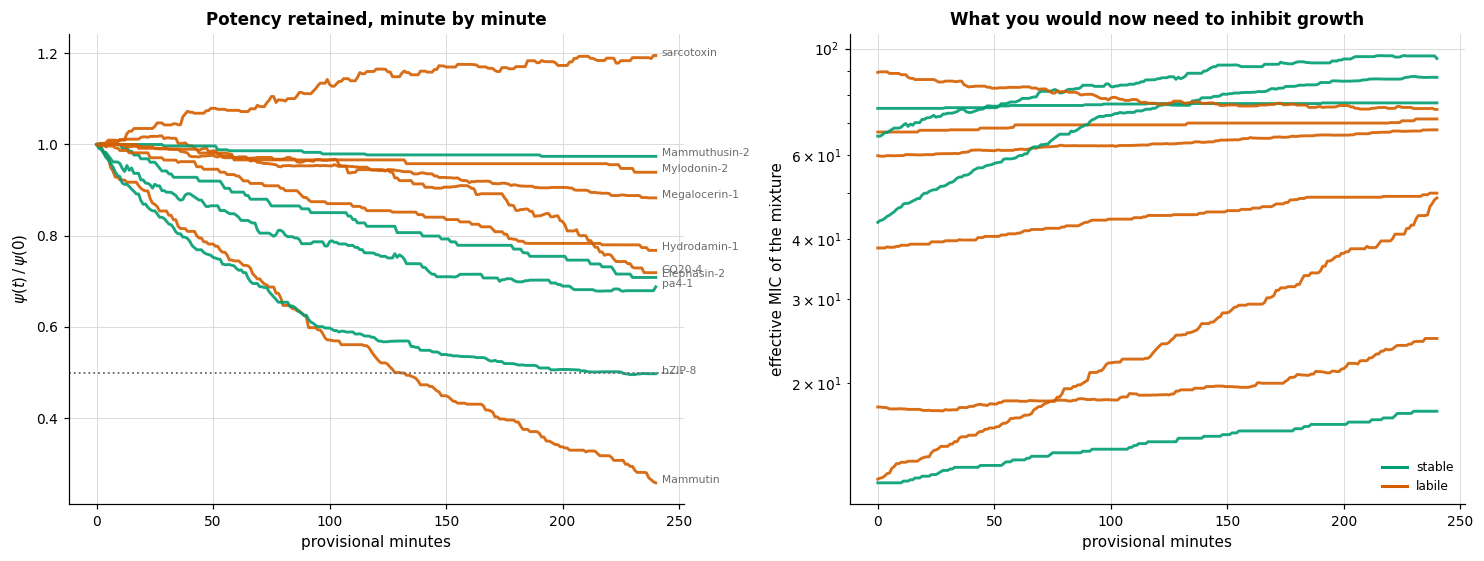

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13.6, 5.2), sharex=True)

ax = axes[0]
for short, group in main.groupby("short"):
    fate = group["serum_fate"].iloc[0]
    colour = common.CATEGORICAL_COLORS[2] if fate == "stable" else common.CATEGORICAL_COLORS[1]
    ax.plot(group["minute"], group["relative_potency"], color=colour, linewidth=1.9, alpha=0.9)
    ax.annotate(short, (group["minute"].iloc[-1], group["relative_potency"].iloc[-1]),
                textcoords="offset points", xytext=(4, 0), fontsize=7, color=common.NEUTRAL)
ax.axhline(0.5, color=common.NEUTRAL, linestyle=":", linewidth=1.2)
ax.set_xlabel("provisional minutes")
ax.set_ylabel(r"$\psi(t)\,/\,\psi(0)$")
ax.set_title("Potency retained, minute by minute")

ax = axes[1]
for short, group in main.groupby("short"):
    fate = group["serum_fate"].iloc[0]
    colour = common.CATEGORICAL_COLORS[2] if fate == "stable" else common.CATEGORICAL_COLORS[1]
    ax.plot(group["minute"], group["effective_mic"], color=colour, linewidth=1.9, alpha=0.9)
ax.set_yscale("log")
ax.set_xlabel("provisional minutes")
ax.set_ylabel("effective MIC of the mixture")
ax.set_title("What you would now need to inhibit growth")
handles = [
    plt.Line2D([], [], color=colour, linewidth=2, label=fate)
    for fate, colour in (("stable", common.CATEGORICAL_COLORS[2]), ("labile", common.CATEGORICAL_COLORS[1]))
]
ax.legend(handles=handles, frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

## How the killing power accumulates, under every transform

Potency is not killing. A transform turns the potency sum into a rate of killing,
and the transforms disagree about what a given $\psi$ is worth. The cumulative
budget

$$B(T) = \int_0^T A(\psi(t))\,\mathrm{d}t$$

is how much killing the molecule has delivered by minute $T$, and its shape over
the first minutes is what a dosing decision depends on. Every registered transform
is applied to the same trajectories.

In [11]:
budget_rows = []
for (short, weighting), group in trajectories.groupby(["short", "weighting"]):
    group = group.sort_values("minute")
    potency = group["relative_potency"].to_numpy()
    minute = group["minute"].to_numpy()
    fate = group["serum_fate"].iloc[0]
    for name in activity_transform_registry.names():
        transform = build_activity_transform(name)
        activity = np.asarray(transform(potency), dtype=float)
        intact_activity = float(np.asarray(transform(np.array([1.0])), dtype=float)[0])
        ## The integral over a single point is undefined, so minute zero delivers
        ## nothing by construction and the cumulative starts from the first interval.
        cumulative = np.zeros(len(minute))
        for index in range(1, len(minute)):
            cumulative[index] = activity_budget(minute[: index + 1], activity[: index + 1])
        budget_rows.append(
            pd.DataFrame(
                {
                    "short": short, "serum_fate": fate, "weighting": weighting, "transform": name,
                    "minute": minute, "activity": activity,
                    "cumulative_budget": cumulative,
                    "ideal_budget": intact_activity * minute,
                }
            )
        )

budgets = pd.concat(budget_rows, ignore_index=True)
final = budgets[(budgets["weighting"] == "concentration") & (budgets["minute"] == times[-1])]
delivered = final.assign(
    share_of_ideal=lambda f: np.where(f["ideal_budget"] != 0, f["cumulative_budget"] / f["ideal_budget"], np.nan)
)
print(f"share of the ideal budget delivered by minute {times[-1]:.0f}, by transform and label:")
print(
    delivered.pivot_table(index="transform", columns="serum_fate", values="share_of_ideal", aggfunc="median")
    .round(3).to_string()
)

share of the ideal budget delivered by minute 240, by transform and label:
serum_fate      labile  stable
transform                     
hill_kill_rate   0.962   0.890
potency_sum      0.929   0.807
soft_threshold   0.962   0.890
threshold        0.046   0.025


### Reading the figure

One panel per transform. Each line is a control peptide's cumulative killing,
against the dotted line a peptide that never degraded would follow. The gap that
opens between a curve and that line is what proteolysis costs, and how early it
opens is what a dosing interval has to respect. A transform whose panel shows no
gap for any peptide is one that cannot express the cost at all.

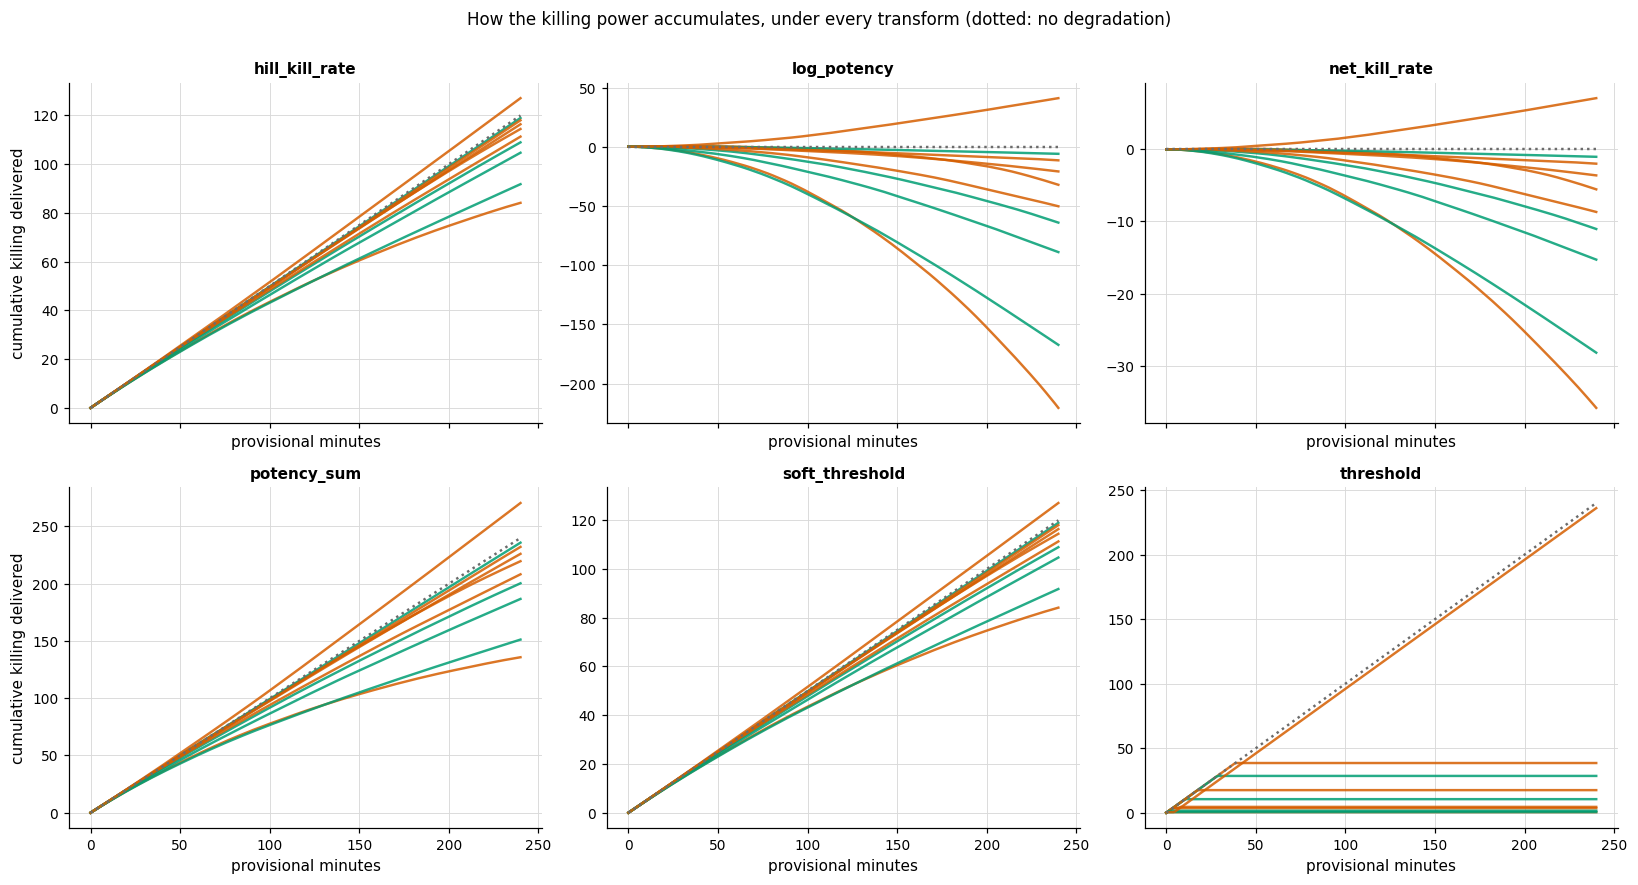

In [12]:
names = list(activity_transform_registry.names())
fig, axes = plt.subplots(2, 3, figsize=(15.0, 8.0), sharex=True)
for ax, name in zip(axes.ravel(), names):
    subset = budgets[(budgets["weighting"] == "concentration") & (budgets["transform"] == name)]
    for short, group in subset.groupby("short"):
        fate = group["serum_fate"].iloc[0]
        colour = common.CATEGORICAL_COLORS[2] if fate == "stable" else common.CATEGORICAL_COLORS[1]
        ax.plot(group["minute"], group["cumulative_budget"], color=colour, linewidth=1.6, alpha=0.85)
    reference = subset[subset["short"] == subset["short"].iloc[0]]
    ax.plot(reference["minute"], reference["ideal_budget"], color=common.NEUTRAL,
            linestyle=":", linewidth=1.6)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("provisional minutes")
axes[0, 0].set_ylabel("cumulative killing delivered")
axes[1, 0].set_ylabel("cumulative killing delivered")
fig.suptitle("How the killing power accumulates, under every transform (dotted: no degradation)", y=1.0, fontsize=11)
fig.tight_layout()
plt.show()

In [13]:
common.save_result(hazard, "4_04_control_hazard.csv")
common.save_result(expected, "4_04_control_single_cut.csv")
common.save_result(trajectories, "4_04_control_trajectories.csv")
common.save_result(delivered[["short", "serum_fate", "transform", "cumulative_budget", "ideal_budget", "share_of_ideal"]],
                   "4_04_control_budgets.csv")

PosixPath('/home/max/repositories/pep-compass/assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/4_04_control_budgets.csv')

## Findings and decisions

**The annotated groups do not come apart at any of the four levels, and at level 2
they come apart backwards.**

*Level 1, the hazard.* AUC 0.58 (uniform), 0.42 (concentration), 0.52 (switched
off), none distinguishable from chance. This repeats `3_03` on the same peptides.

*Level 2, the single cut.* Ordered by the potency a first cleavage is expected to
leave behind:

| peptide | label | expected potency left |
| --- | --- | --- |
| Elephasin-2 | **stable** | **0.121** |
| Mylodonin-2 | labile | 0.342 |
| Hydrodamin-1 | labile | 0.464 |
| Mammutin | labile | 0.495 |
| Mammuthusin-2 | stable | 0.529 |
| bZIP-8 | stable | 0.634 |
| pa4-1 | stable | 0.719 |
| Megalocerin-1 | labile | 0.947 |
| GQ20-4 | labile | 0.964 |
| sarcotoxin | **labile** | **1.274** |

The peptide with the most to lose from a single cut is annotated **stable**, and the
one whose cut *raises* the potency sum is annotated **labile**. The ordering is not
merely uninformative, it is reversed at both ends.

*Levels 3 and 4, the time course.* Only **two of ten** peptides lose half their
potency within four hours — Mammutin at 128 minutes and bZIP-8 at 226 — while six
are annotated labile. At the calibrated offset the model says these molecules
survive four hours essentially intact, which is not what the annotation claims.

**A methodological consequence that has nothing to do with the labels: the
`threshold` transform is unusable at this dose.** It delivers 4.6% of the ideal
budget on labile peptides and 2.5% on stable ones, against 89% to 96% for
`hill_kill_rate` and `soft_threshold`. The reason is the dose convention itself. The
dose was set to exactly one MIC so that $\psi$ starts at 1 and the effective MIC is
directly readable, which places `threshold` — an indicator at $\psi \ge 1$ — exactly
on its own discontinuity. Any cleavage at all, however small its effect, drops the
peptide below the step and zeroes the activity for the rest of the horizon.

That is a knife-edge artefact of the two conventions meeting, not a property of the
peptides. `threshold` needs a dose strictly above one MIC to mean anything, and any
comparison of transforms has to state the dose it was made at.

**The signed transforms cannot be summarised as a share of an ideal.**
`log_potency` and `net_kill_rate` are both zero at $\psi = 1$, so the ideal budget
they are measured against is zero and the ratio is undefined; they are absent from
the table for that reason rather than by omission. The cumulative panels show them
directly, which is the only honest way to read them.

**What this notebook settles and what it does not.** It settles that the four links
now run on one set of molecules, so a disagreement between links can no longer be a
disagreement between samples. It does not settle whether the model can discriminate
serum stability — `3_03` established that this annotation is too weak and too
confounded to decide that, and the inverted ordering at level 2 is as likely to be a
property of the labels as of the model. What it does show, with no reference to the
labels at all, is that at the calibrated time axis the model predicts almost no
potency loss over four hours for eight of these ten peptides.